In [2]:
import shap
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

shap.initjs()

d:\Desktop\ENGG\E3_Mini_Project\Building_Energy_Consumption_Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
with open("../models/xgb_time_model.pkl", "rb") as f:
    model = pickle.load(f)

print("✅ Model loaded")

✅ Model loaded


In [4]:
df = pd.read_feather("../data/cleaned_data.feather")

print(df.shape)

(20216100, 18)


In [5]:
target = "meter_reading_log"

X = df.drop(columns=[target, "building_id", "energy_per_sqft"])
y = df[target]

print(X.shape)

(20216100, 15)


In [6]:
X_sample = X.sample(2000, random_state=42)

print(X_sample.shape)

(2000, 15)


In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

print("SHAP values computed")

SHAP values computed


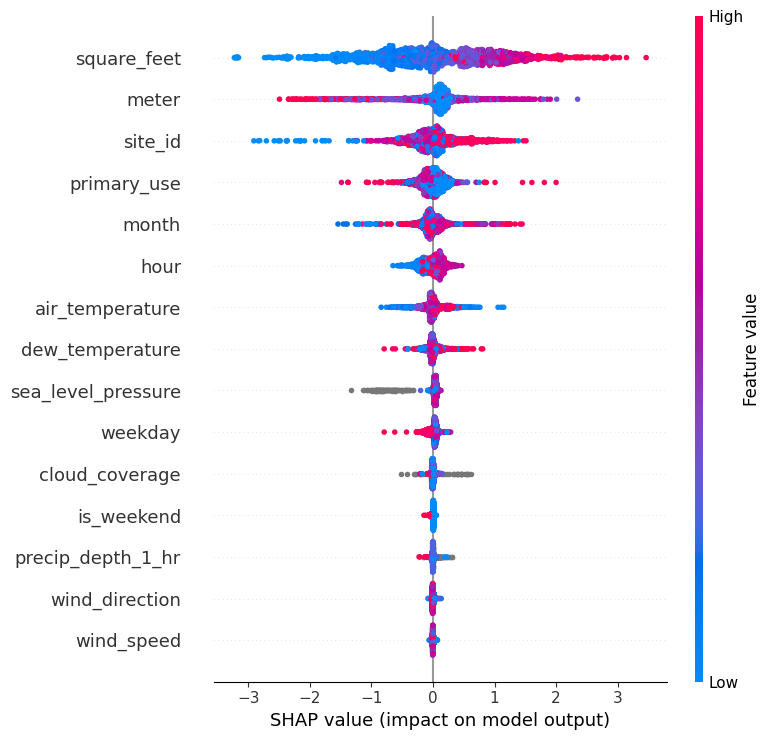

In [8]:
shap.summary_plot(shap_values, X_sample)

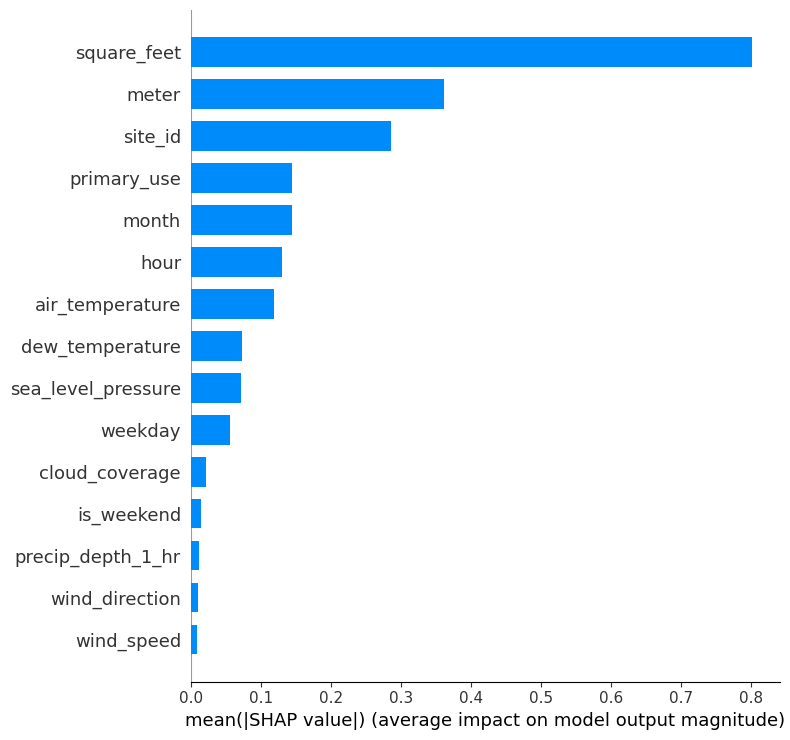

In [9]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

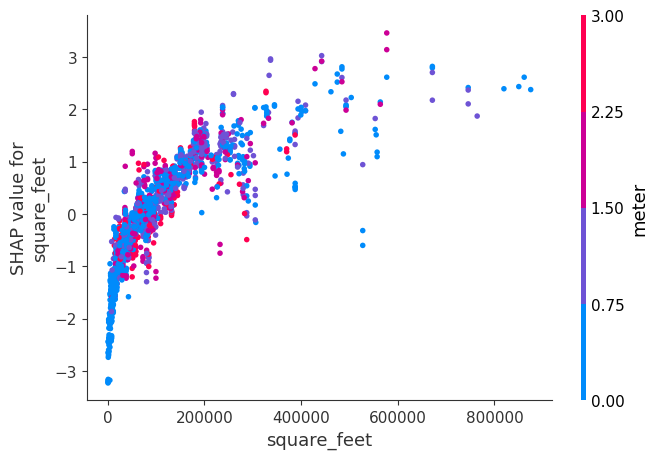

In [10]:
shap.dependence_plot("square_feet", shap_values, X_sample)

In [11]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0]
)

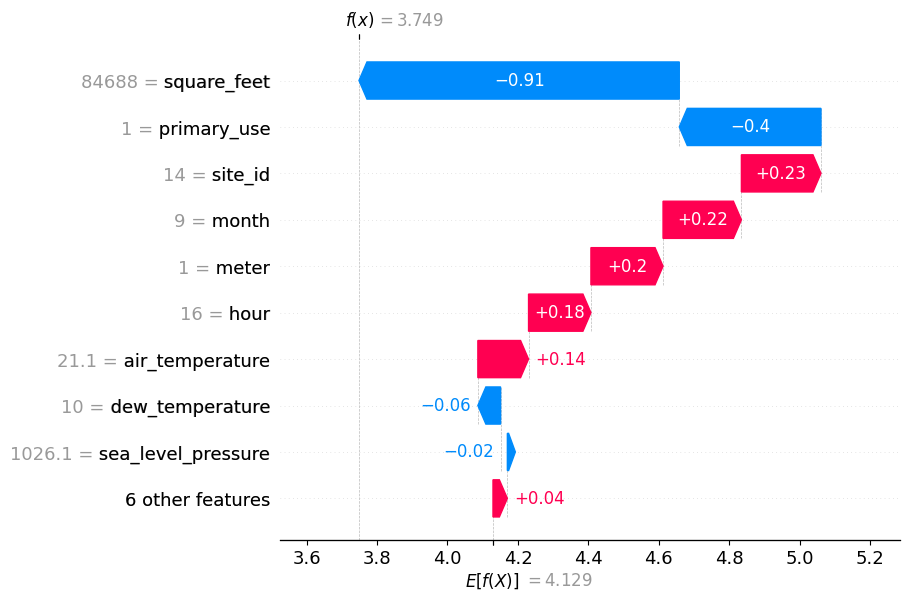

In [12]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample.iloc[0],
        feature_names=X_sample.columns
    )
)

In [13]:
new_building = pd.DataFrame({
    "meter":[1],
    "site_id":[5],
    "primary_use":[2],
    "square_feet":[120000],
    "air_temperature":[30],
    "cloud_coverage":[4],
    "dew_temperature":[22],
    "precip_depth_1_hr":[0],
    "sea_level_pressure":[1015],
    "wind_direction":[200],
    "wind_speed":[3],
    "hour":[14],
    "month":[7],
    "weekday":[3],
    "is_weekend":[0]
})

In [14]:
pred = model.predict(new_building)
print(pred)

[6.1793885]


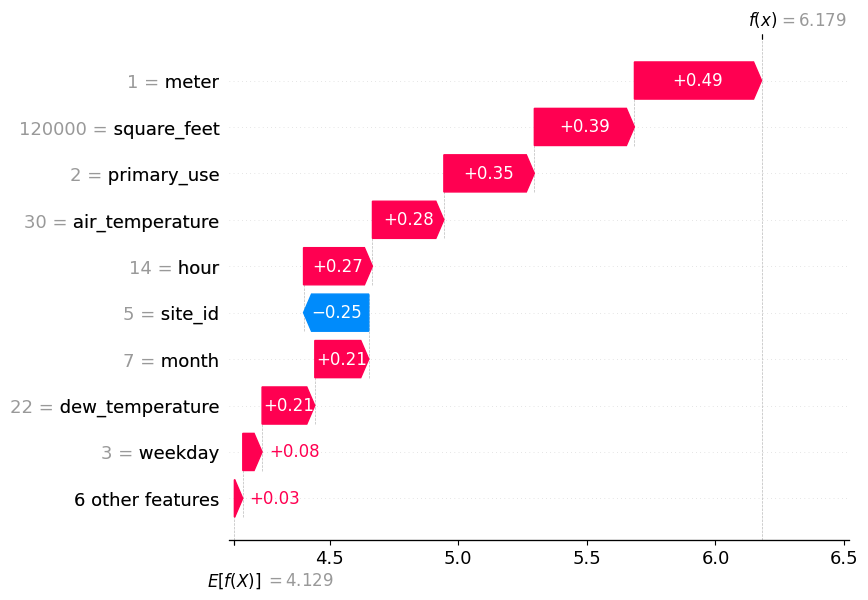

In [15]:
shap_val = explainer.shap_values(new_building)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_val[0],
        base_values=explainer.expected_value,
        data=new_building.iloc[0],
        feature_names=new_building.columns
    )
)

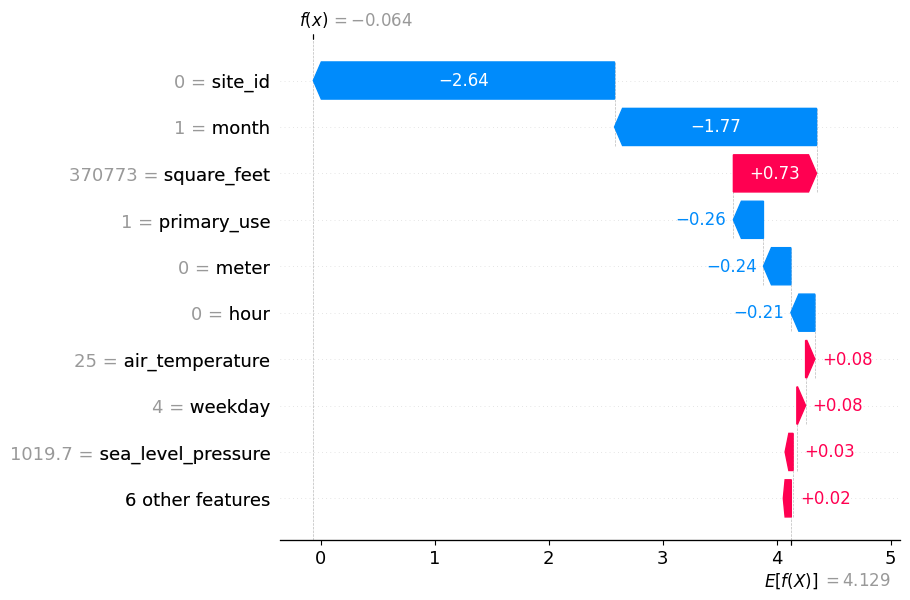

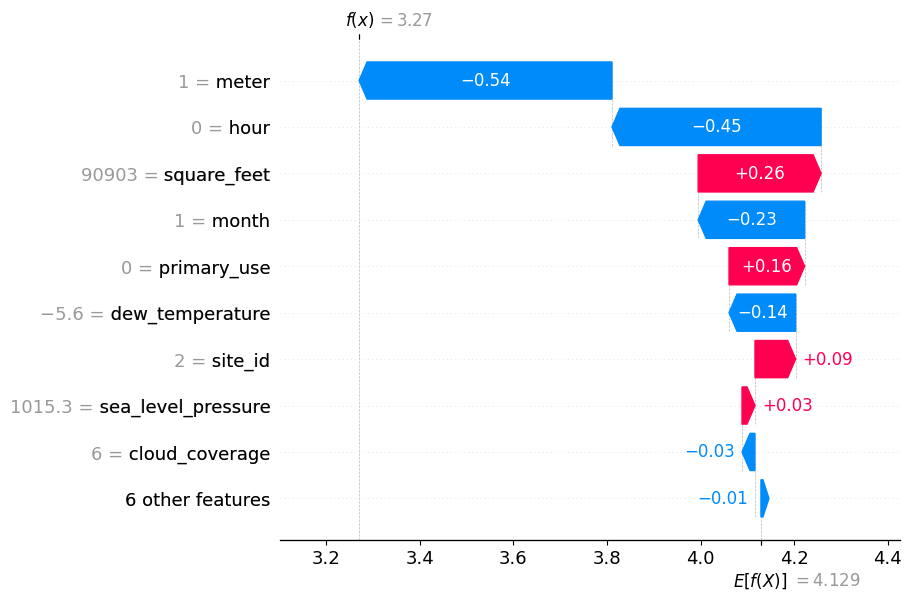

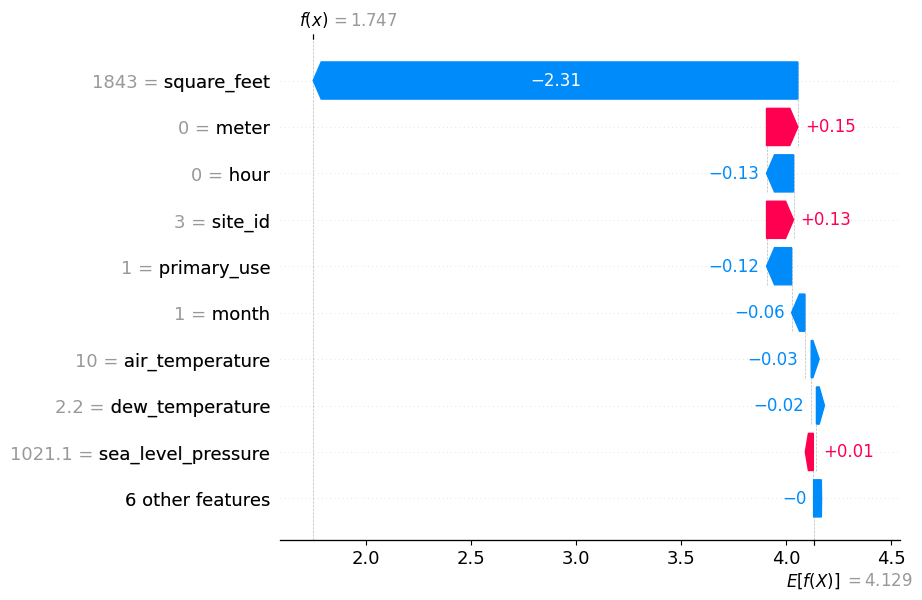

In [16]:
for i in [10, 200, 500]:
    sample = X.iloc[[i]]
    
    shap_val = explainer.shap_values(sample)
    
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_val[0],
            base_values=explainer.expected_value,
            data=sample.iloc[0],
            feature_names=sample.columns
        )
    )

In [17]:
shap_val = explainer.shap_values(new_building)

In [18]:
def explain_prediction(model, explainer, X_input):

    shap_values = explainer.shap_values(X_input)[0]

    prediction = model.predict(X_input)[0]

    base = explainer.expected_value

    features = X_input.columns
    values = X_input.iloc[0]

    explanation = []

    explanation.append(f"The predicted log energy consumption is {prediction:.3f}.")

    explanation.append(f"The average baseline prediction of the model is {base:.3f}.")

    explanation.append("The prediction changed due to the following factors:")

    for f, val, shap_val in zip(features, values, shap_values):

        if shap_val > 0:
            explanation.append(
                f"- {f} = {val} increased the prediction by {abs(shap_val):.2f}"
            )

        elif shap_val < 0:
            explanation.append(
                f"- {f} = {val} decreased the prediction by {abs(shap_val):.2f}"
            )

    return "\n".join(explanation)

In [19]:
print(explain_prediction(model, explainer, new_building))

The predicted log energy consumption is 6.179.
The average baseline prediction of the model is 4.129.
The prediction changed due to the following factors:
- meter = 1 increased the prediction by 0.49
- site_id = 5 decreased the prediction by 0.25
- primary_use = 2 increased the prediction by 0.35
- square_feet = 120000 increased the prediction by 0.39
- air_temperature = 30 increased the prediction by 0.28
- cloud_coverage = 4 decreased the prediction by 0.00
- dew_temperature = 22 increased the prediction by 0.21
- precip_depth_1_hr = 0 decreased the prediction by 0.00
- sea_level_pressure = 1015 increased the prediction by 0.04
- wind_direction = 200 decreased the prediction by 0.01
- wind_speed = 3 decreased the prediction by 0.00
- hour = 14 increased the prediction by 0.27
- month = 7 increased the prediction by 0.21
- weekday = 3 increased the prediction by 0.08
- is_weekend = 0 increased the prediction by 0.01


In [20]:
import sys
sys.path.append('../utils')

from feature_labels import get_feature_label, get_value_label

print("=== Feature Names ===")

for col in new_building.columns:
    print(f"{col:25} -> {get_feature_label(col)}")


print("\n=== Value Decoding ===")

for col in new_building.columns:
    val = new_building[col].iloc[0]
    print(f"{col:25} = {val:10} -> {get_value_label(col, val)}")

=== Feature Names ===
meter                     -> Energy Meter Type
site_id                   -> City
primary_use               -> Building Type
square_feet               -> Building Area (sq ft)
air_temperature           -> Outdoor Temperature (°C)
cloud_coverage            -> Cloud Coverage
dew_temperature           -> Dew Point Temperature (°C)
precip_depth_1_hr         -> Rainfall (mm/hr)
sea_level_pressure        -> Sea Level Pressure (hPa)
wind_direction            -> Wind Direction
wind_speed                -> Wind Speed (m/s)
hour                      -> Hour of Day
month                     -> Month
weekday                   -> Day of Week
is_weekend                -> Weekend Indicator

=== Value Decoding ===
meter                     =          1 -> 1
site_id                   =          5 -> 5
primary_use               =          2 -> 2
square_feet               =     120000 -> 120000
air_temperature           =         30 -> 30
cloud_coverage            =          4 -> 4
d

In [21]:
import sys
sys.path.append('../utils')

from recommendations import generate_recommendations, format_recommendations

# Use your existing shap_val and new_building
shap_values  = explainer.shap_values(new_building)[0]
feature_names = new_building.columns.tolist()
feature_values = new_building.iloc[0].tolist()

# Generate recommendations
recs = generate_recommendations(shap_values, feature_names, feature_values)

# Print formatted output
print(format_recommendations(recs))

ENERGY SAVING RECOMMENDATIONS

1. Energy Meter Type: 1
   Impact: +0.50 on log scale
   Action: Your meter type indicates high energy demand. Review equipment schedules and consider switching to more energy efficient systems where possible.
   Estimated Saving: 5-10%

2. Building Area (sq ft): 120000
   Impact: +0.39 on log scale
   Action: Your building size is a major energy driver. Consider implementing HVAC zoning to heat/cool only occupied areas instead of the entire building.
   Estimated Saving: 8-15%

3. Building Type: 2
   Impact: +0.35 on log scale
   Action: Buildings of this type typically benefit from occupancy-based controls. Install smart sensors to automatically reduce energy use in empty spaces.
   Estimated Saving: 7-13%

Total Potential Saving: 20-38%


In [22]:
print(df['primary_use'].value_counts())
print(df['primary_use'].unique())

primary_use
0     8165504
6     4394864
1     2264917
4     2146413
9     1662826
3      398527
7      242222
8      213796
5      125713
2      114090
11     112657
15     111861
12      96519
13      77627
14      56203
10      32361
Name: count, dtype: int64
[ 0  4  6  1  7 11  8  9 15  2 10  3 14 13  5 12]


In [23]:
print("=== site_id ===")
print(df['site_id'].value_counts().sort_index())

print("\n=== meter ===")
print(df['meter'].value_counts().sort_index())

print("\n=== primary_use ===")
print(df['primary_use'].value_counts().sort_index())

=== site_id ===
site_id
0     1076662
1      553357
2     2530312
3     2370097
4      746746
5      781776
6      668133
7      366681
8      567915
9     2679323
10     411407
11     119459
12     315909
13    2711763
14    2501506
15    1815054
Name: count, dtype: int64

=== meter ===
meter
0    12060910
1     4182440
2     2708713
3     1264037
Name: count, dtype: int64

=== primary_use ===
primary_use
0     8165504
1     2264917
2      114090
3      398527
4     2146413
5      125713
6     4394864
7      242222
8      213796
9     1662826
10      32361
11     112657
12      96519
13      77627
14      56203
15     111861
Name: count, dtype: int64


In [25]:
import sys
import os

# Go one level up from notebooks/ to find utils/
sys.path.insert(0, os.path.abspath('../utils'))

# Now import directly
from importlib import reload
import feature_labels as fl
reload(fl)
from feature_labels import get_feature_label, get_value_label

print("=== Value Decoding ===")
for col in new_building.columns:
    val = new_building[col].iloc[0]
    print(f"{col:25} = {str(val):10} -> {get_value_label(col, val)}")

=== Value Decoding ===
meter                     = 1          -> Chilled Water
site_id                   = 5          -> Site 5
primary_use               = 2          -> Food Sales and Service
square_feet               = 120000     -> 120,000
air_temperature           = 30         -> 30.0 C
cloud_coverage            = 4          -> 4
dew_temperature           = 22         -> 22.0 C
precip_depth_1_hr         = 0          -> 0.0 mm
sea_level_pressure        = 1015       -> 1015.0 hPa
wind_direction            = 200        -> 200 deg
wind_speed                = 3          -> 3.0 m/s
hour                      = 14         -> 14:00
month                     = 7          -> July
weekday                   = 3          -> Thursday
is_weekend                = 0          -> No


In [26]:
import sys
import os
sys.path.insert(0, os.path.abspath('../utils'))

from importlib import reload
import recommendations as rec_module
reload(rec_module)
from recommendations import generate_recommendations, format_recommendations

recs = generate_recommendations(shap_values, feature_names, feature_values)
print(format_recommendations(recs))

ENERGY SAVING RECOMMENDATIONS

1. Energy Meter Type: Chilled Water
   Impact: +0.50 on log scale
   Action: Your meter type indicates high energy demand. Review equipment schedules and consider switching to more energy efficient systems where possible.
   Estimated Saving: 5-10%

2. Building Area (sq ft): 120,000
   Impact: +0.39 on log scale
   Action: Your building size is a major energy driver. Consider implementing HVAC zoning to heat/cool only occupied areas instead of the entire building.
   Estimated Saving: 8-15%

3. Building Type: Food Sales and Service
   Impact: +0.35 on log scale
   Action: Buildings of this type typically benefit from occupancy-based controls. Install smart sensors to automatically reduce energy use in empty spaces.
   Estimated Saving: 7-13%

Total Potential Saving: 20-38%
